# Feito e Produzido por
> *Luis Augusto de souza & Luiz Gustavo Gomes Damasceno*



# 2.7 - 16

16. O deslocamento (em metros) de uma partícula movendo-se ao longo de uma reta é dado pela equação té medido em segundos. onde s = t ^ 2 - 8t + 18

(a) Encontre as velocidades médias sobre os seguintes intervalos de tempo:

(i) [3,4]

(ii) [3,5; 4]

(iii) [4, 5]

(iv) [4; 4,5]

(b) Encontre a velocidade instantânea quando t = 4

(c) Faça o gráfico de s como uma função de te desenhe as retas secantes cujas inclinações são as velocidades médias da parte (a), e a reta tangente cuja inclinação é a velocidade instantâ-nea da parte (b).


EXERCÍCIO 16 – Partícula em Movimento

  s(t) = t**2 - 8*t + 18
  s'(t) = v(t) = 2*t - 8   ← derivada analítica

(a) Velocidades médias:
    [3, 4]        →  vm = Δs/Δt = -1.0000 m/s
    [3.5, 4]      →  vm = Δs/Δt = -0.5000 m/s
    [4, 5]        →  vm = Δs/Δt = +1.0000 m/s
    [4, 4.5]      →  vm = Δs/Δt = +0.5000 m/s

(b) Velocidade instantânea em t = 4:
    v(4) = s'(4) = 0 = 0.0 m/s

    (Limite geométrico: as secantes convergem para 0.0 m/s)

    Confirmação via limite:
    lim_{h→0} [s(4+h) - s(4)] / h = 0


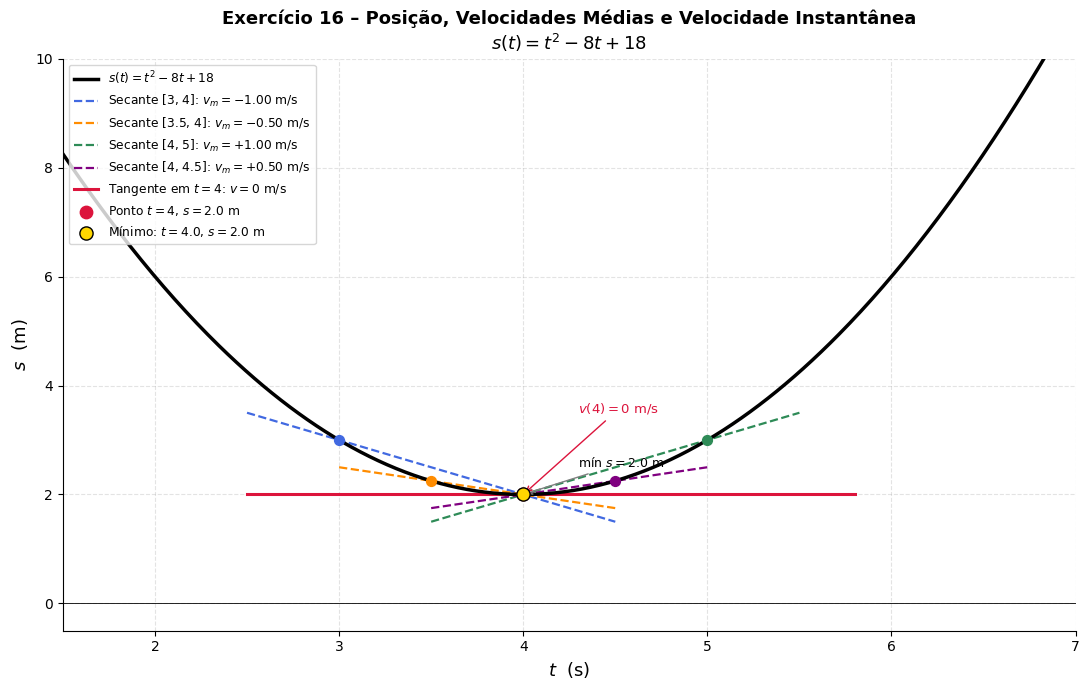


Gráfico salvo em: exercicio16_particula.png


In [ ]:
# codigo da 2.7 - 16

"""
Exercício 16 – Deslocamento de uma partícula
─────────────────────────────────────────────
s(t) = t² − 8t + 18   (metros, t em segundos)

(a) Velocidades médias nos intervalos:
    (i) [3,4]   (ii) [3.5,4]   (iii) [4,5]   (iv) [4,4.5]
(b) Velocidade instantânea em t = 4
(c) Gráfico de s(t) com retas secantes e tangente
"""

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ══════════════════════════════════════════════
# 1.  DEFINIÇÃO SIMBÓLICA  (solução analítica)
# ══════════════════════════════════════════════
t = sp.Symbol('t', real=True)
s_expr = t**2 - 8*t + 18

# Derivada simbólica → velocidade instantânea
v_expr = sp.diff(s_expr, t)

s = sp.lambdify(t, s_expr, 'numpy')   # versão numérica
v = sp.lambdify(t, v_expr, 'numpy')   # versão numérica

print("=" * 55)
print("EXERCÍCIO 16 – Partícula em Movimento")
print("=" * 55)
print(f"\n  s(t) = {s_expr}")
print(f"  s'(t) = v(t) = {v_expr}   ← derivada analítica")

# ══════════════════════════════════════════════
# 2.  VELOCIDADE MÉDIA  Δs/Δt  (analítica)
# ══════════════════════════════════════════════
def vel_media(t1, t2):
    """Velocidade média no intervalo [t1, t2] via fórmula analítica."""
    delta_s = sp.simplify(s_expr.subs(t, t2) - s_expr.subs(t, t1))
    delta_t = t2 - t1
    vm = sp.Rational(delta_s, delta_t) if isinstance(delta_t, int) else delta_s / delta_t
    return float(vm)

intervalos = [(3, 4), (3.5, 4), (4, 5), (4, 4.5)]
labels_int = ["[3, 4]", "[3.5, 4]", "[4, 5]", "[4, 4.5]"]
cores_sec  = ["royalblue", "darkorange", "seagreen", "purple"]

print("\n(a) Velocidades médias:")
vms = []
for (t1, t2), lbl in zip(intervalos, labels_int):
    vm = vel_media(t1, t2)
    vms.append(vm)
    print(f"    {lbl:12s}  →  vm = Δs/Δt = {vm:+.4f} m/s")

# ══════════════════════════════════════════════
# 3.  VELOCIDADE INSTANTÂNEA em t = 4  (analítica)
# ══════════════════════════════════════════════
t0 = 4
v_inst = float(v_expr.subs(t, t0))
s0     = float(s_expr.subs(t, t0))

print(f"\n(b) Velocidade instantânea em t = {t0}:")
print(f"    v({t0}) = s'({t0}) = {v_expr.subs(t,t0)} = {v_inst} m/s")
print(f"\n    (Limite geométrico: as secantes convergem para {v_inst} m/s)")

# ══════════════════════════════════════════════
# 4.  VERIFICAÇÃO PELO LIMITE  lim h→0  Δs/Δt
# ══════════════════════════════════════════════
h = sp.Symbol('h')
limite = sp.limit((s_expr.subs(t, t0 + h) - s_expr.subs(t, t0)) / h, h, 0)
print(f"\n    Confirmação via limite:")
print(f"    lim_{{h→0}} [s({t0}+h) - s({t0})] / h = {limite}")

# ══════════════════════════════════════════════
# 5.  GRÁFICO  (solução gráfica e geométrica)
# ══════════════════════════════════════════════
t_arr = np.linspace(1, 7, 500)
s_arr = s(t_arr)

fig, ax = plt.subplots(figsize=(11, 7))

# ── curva principal ──────────────────────────
ax.plot(t_arr, s_arr, color="black", linewidth=2.5,
        label=r"$s(t) = t^2 - 8t + 18$", zorder=3)

# ── retas secantes ───────────────────────────
for (t1, t2), lbl, vm, cor in zip(intervalos, labels_int, vms, cores_sec):
    s1, s2 = s(t1), s(t2)
    # estende a reta secante para visualização
    t_ext = np.array([min(t1, t2) - 0.5, max(t1, t2) + 0.5])
    s_ext = s(t1) + vm * (t_ext - t1)
    ax.plot(t_ext, s_ext, linestyle="--", linewidth=1.6, color=cor,
            label=rf"Secante {lbl}: $v_m={vm:+.2f}$ m/s")
    ax.scatter([t1, t2], [s1, s2], color=cor, zorder=5, s=50)

# ── reta tangente em t = 4 ───────────────────
t_tan = np.linspace(2.5, 5.8, 200)
s_tan = s0 + v_inst * (t_tan - t0)
ax.plot(t_tan, s_tan, color="crimson", linewidth=2.2,
        label=rf"Tangente em $t=4$: $v={v_inst:.0f}$ m/s")
ax.scatter([t0], [s0], color="crimson", zorder=6, s=80,
           label=rf"Ponto $t=4$, $s={s0:.1f}$ m")

# ── ponto de mínimo de s(t) ──────────────────
t_min = float(sp.solve(v_expr, t)[0])          # s'(t)=0
s_min = float(s_expr.subs(t, t_min))
ax.scatter([t_min], [s_min], color="gold", edgecolors="black",
           zorder=7, s=90, label=rf"Mínimo: $t={t_min}$, $s={s_min}$ m")
ax.annotate(rf"mín $s={s_min}$ m", xy=(t_min, s_min),
            xytext=(t_min + 0.3, s_min + 0.5), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))

# ── anotação da tangente ─────────────────────
ax.annotate(rf"$v({t0}) = {v_inst:.0f}$ m/s",
            xy=(t0, s0), xytext=(t0 + 0.3, s0 + 1.5),
            fontsize=9.5, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson"))

# ── formatação ───────────────────────────────
ax.set_xlabel(r"$t$  (s)", fontsize=13)
ax.set_ylabel(r"$s$  (m)", fontsize=13)
ax.set_title(
    "Exercício 16 – Posição, Velocidades Médias e Velocidade Instantânea\n"
    r"$s(t) = t^2 - 8t + 18$",
    fontsize=13, fontweight="bold"
)
ax.set_xlim(1.5, 7)
ax.set_ylim(-0.5, 10)
ax.axhline(0, color="black", linewidth=0.6)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=8.8, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("exercicio16_particula.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGráfico salvo em: exercicio16_particula.png")


# 2.8 - 14

14. O gráfico (do Departamento de Energia dos EUA) mostra como a velocidade do carro afeta o rendimento do combustível. O ren-dimento do combustível Fé medido em milhas por galão e a ve-locidade v é medida em milhas por hora.

(a) Qual o significado da derivada F' * (v)

(b) Esboce o gráfico de F' * (v)

(c) Em qual velocidade você deve dirigir se quer economizar combustível?


EXERCÍCIO 14 – Rendimento do Combustível

(a) Significado de F'(v):
    F'(v) é a taxa de variação do rendimento do
    combustível em relação à velocidade.
    Unidade: (mi/gal) / (mi/h)  =  h/gal
    • F'(v) > 0  →  aumentar a velocidade MELHORA
                    o rendimento.
    • F'(v) < 0  →  aumentar a velocidade PIORA
                    o rendimento.
    • F'(v) = 0  →  velocidade de rendimento máximo.

(c) Velocidade ideal: v* ≈ 52.9 mi/h
    Rendimento máximo: F(v*) ≈ 30.3 mi/gal



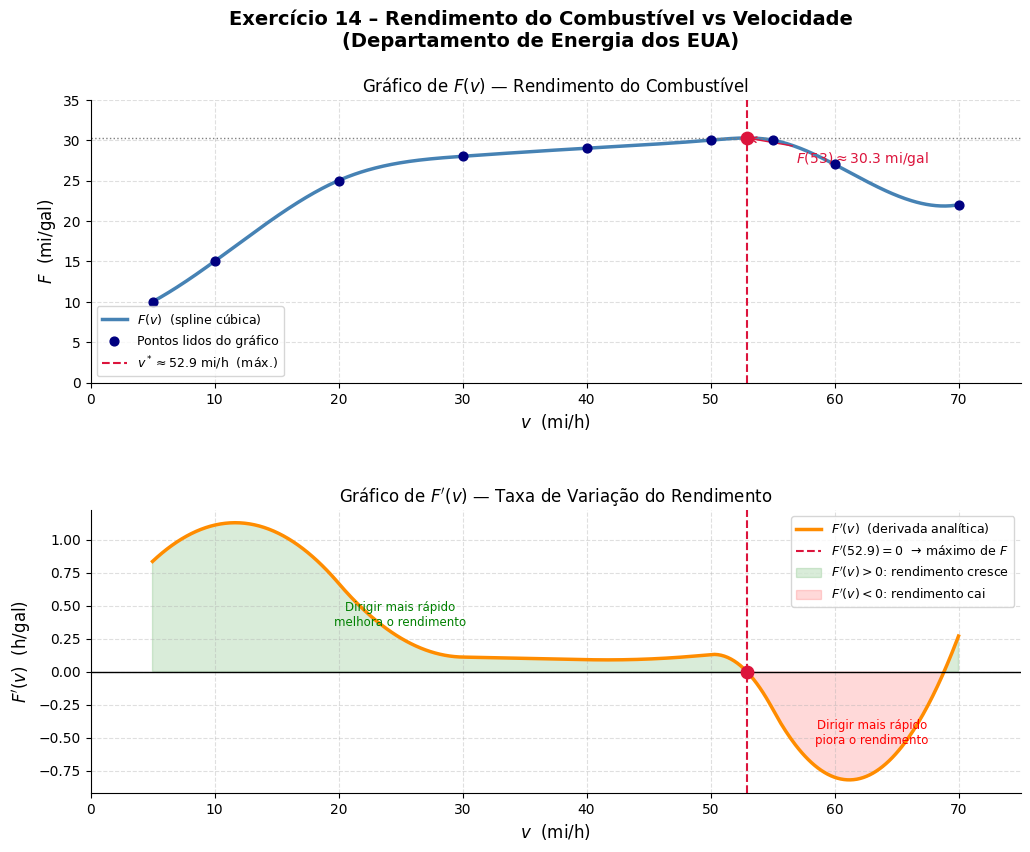

Gráfico salvo em: exercicio14_combustivel.png


In [ ]:
# codigo da 2.8 - 14
"""
Exercício 14 - Cálculo: Rendimento do Combustível x Velocidade
-----------------------------------------------------------------
O gráfico (Departamento de Energia dos EUA) mostra como a velocidade
do carro afeta o rendimento do combustível.
  - F: rendimento do combustível (mi/gal)
  - v: velocidade (mi/h)

(a) Significado de F'(v)
(b) Esboço do gráfico de F'(v)
(c) Velocidade ideal para economizar combustível
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import CubicSpline

# ─────────────────────────────────────────────
# 1.  DADOS RETIRADOS DO GRÁFICO (digitalização)
#     Pontos (v, F) aproximados visualmente
# ─────────────────────────────────────────────
v_pts = np.array([ 5,  10,  20,  30,  40,  50,  55,  60,  70])
F_pts = np.array([10,  15,  25,  28,  29,  30,  30,  27,  22])

# ─────────────────────────────────────────────
# 2.  INTERPOLAÇÃO CÚBICA  (solução analítica local)
# ─────────────────────────────────────────────
cs = CubicSpline(v_pts, F_pts)          # spline cúbica natural
cs_deriv = cs.derivative()              # F'(v)  analítica via spline

v = np.linspace(5, 70, 500)            # domínio contínuo
F = cs(v)
dF = cs_deriv(v)

# ─────────────────────────────────────────────
# 3.  PONTO DE MÁXIMO  (F'(v*) = 0)
# ─────────────────────────────────────────────
from scipy.optimize import brentq

# localiza a raiz de F'(v) no intervalo onde há troca de sinal
# (entre o pico e o lado direito decrescente)
sign_changes = np.where(np.diff(np.sign(dF)))[0]
roots = []
for idx in sign_changes:
    try:
        r = brentq(cs_deriv, v[idx], v[idx + 1])
        roots.append(r)
    except ValueError:
        pass

v_star = roots[0] if roots else v[np.argmax(F)]
F_star = cs(v_star)

print("=" * 55)
print("EXERCÍCIO 14 – Rendimento do Combustível")
print("=" * 55)
print()
print("(a) Significado de F'(v):")
print("    F'(v) é a taxa de variação do rendimento do")
print("    combustível em relação à velocidade.")
print("    Unidade: (mi/gal) / (mi/h)  =  h/gal")
print("    • F'(v) > 0  →  aumentar a velocidade MELHORA")
print("                    o rendimento.")
print("    • F'(v) < 0  →  aumentar a velocidade PIORA")
print("                    o rendimento.")
print("    • F'(v) = 0  →  velocidade de rendimento máximo.")
print()
print(f"(c) Velocidade ideal: v* ≈ {v_star:.1f} mi/h")
print(f"    Rendimento máximo: F(v*) ≈ {float(F_star):.1f} mi/gal")
print()

# ─────────────────────────────────────────────
# 4.  FIGURA COM DOIS SUBPLOTS
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(12, 9))
fig.suptitle(
    "Exercício 14 – Rendimento do Combustível vs Velocidade\n"
    "(Departamento de Energia dos EUA)",
    fontsize=14, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(2, 1, hspace=0.45)

# ── Subplot 1: F(v) ──────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(v, F, color="steelblue", linewidth=2.5, label=r"$F(v)$  (spline cúbica)")
ax1.scatter(v_pts, F_pts, color="navy", zorder=5, s=40, label="Pontos lidos do gráfico")
ax1.axvline(v_star, color="crimson", linestyle="--", linewidth=1.5,
            label=rf"$v^* \approx {v_star:.1f}$ mi/h  (máx.)")
ax1.axhline(float(F_star), color="gray", linestyle=":", linewidth=1)
ax1.scatter([v_star], [float(F_star)], color="crimson", zorder=6, s=80)
ax1.annotate(
    rf"$F({v_star:.0f}) \approx {float(F_star):.1f}$ mi/gal",
    xy=(v_star, float(F_star)), xytext=(v_star + 4, float(F_star) - 3),
    fontsize=10, color="crimson",
    arrowprops=dict(arrowstyle="->", color="crimson")
)
ax1.set_xlabel(r"$v$  (mi/h)", fontsize=12)
ax1.set_ylabel(r"$F$  (mi/gal)", fontsize=12)
ax1.set_title(r"Gráfico de $F(v)$ — Rendimento do Combustível", fontsize=12)
ax1.set_xlim(0, 75)
ax1.set_ylim(0, 35)
ax1.set_xticks(range(0, 80, 10))
ax1.legend(fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)
# Eixos no estilo "setas" (geométrico)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── Subplot 2: F'(v) ─────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(v, dF, color="darkorange", linewidth=2.5, label=r"$F'(v)$  (derivada analítica)")
ax2.axhline(0, color="black", linewidth=1)          # eixo horizontal
ax2.axvline(v_star, color="crimson", linestyle="--", linewidth=1.5,
            label=rf"$F'({v_star:.1f}) = 0$  → máximo de $F$")
ax2.scatter([v_star], [0], color="crimson", zorder=6, s=80)

# Regiões coloridas: melhora / piora o rendimento
ax2.fill_between(v, dF, 0, where=(dF >= 0),
                 alpha=0.15, color="green", label=r"$F'(v)>0$: rendimento cresce")
ax2.fill_between(v, dF, 0, where=(dF < 0),
                 alpha=0.15, color="red",   label=r"$F'(v)<0$: rendimento cai")

ax2.set_xlabel(r"$v$  (mi/h)", fontsize=12)
ax2.set_ylabel(r"$F'(v)$  (h/gal)", fontsize=12)
ax2.set_title(r"Gráfico de $F'(v)$ — Taxa de Variação do Rendimento", fontsize=12)
ax2.set_xlim(0, 75)
ax2.set_xticks(range(0, 80, 10))
ax2.legend(fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── Anotações didáticas ──────────────────────
ax2.annotate("Dirigir mais rápido\nmelhora o rendimento",
             xy=(25, 0.35), fontsize=8.5, color="green", ha="center")
ax2.annotate("Dirigir mais rápido\npiora o rendimento",
             xy=(63, -0.55), fontsize=8.5, color="red", ha="center")

plt.savefig("exercicio14_combustivel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em: exercicio14_combustivel.png")

